In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from supervision import draw_image

Text(0.5, 1.0, '')

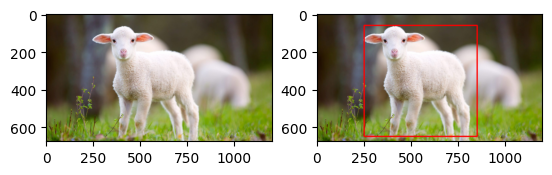

In [20]:
img = cv.imread("../../images/sheep.jpg")
draw_img = img.copy()
rect = (250, 60, 850, 650)
cv.rectangle(draw_img, (rect[0], rect[1]), (rect[2], rect[3]), (0, 0, 255), 5)
plt.subplot(121); plt.imshow(img[...,::-1]); plt.title("")
plt.subplot(122); plt.imshow(draw_img[...,::-1]); plt.title("")

Text(0.5, 1.0, '')

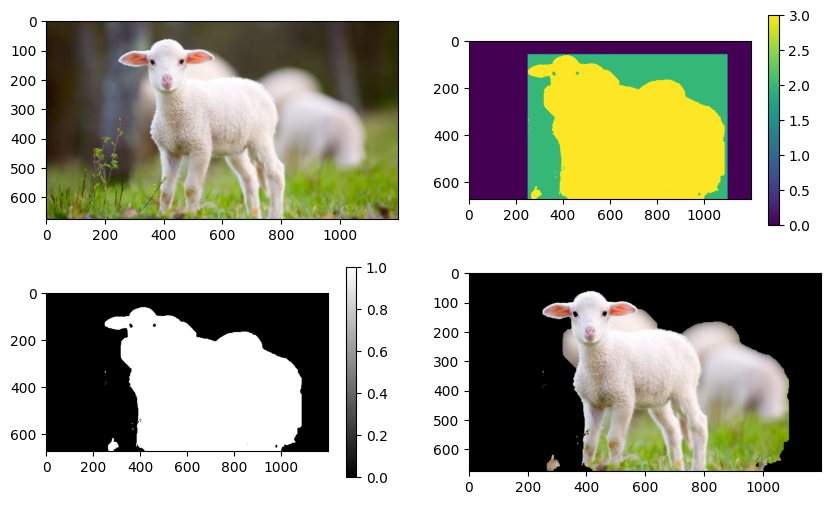

In [23]:
mask = np.zeros(img.shape[:2], dtype="uint8")
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
cv.grabCut(img, mask, rect, bgdModel, fgdModel, 5, mode=cv.GC_INIT_WITH_RECT)

mask2 = np.where((mask == cv.GC_BGD) | (mask == cv.GC_PR_BGD), 0, 1).astype('uint8')
res = cv.bitwise_and(img, img, mask=mask2)

plt.figure(figsize=(10,6))
plt.subplot(221); plt.imshow(img[...,::-1]); plt.title("")
plt.subplot(222); plt.imshow(mask); plt.title(""); plt.colorbar()
plt.subplot(223); plt.imshow(mask2, cmap='gray'); plt.title(""); plt.colorbar()
plt.subplot(224); plt.imshow(res[...,::-1]); plt.title("")

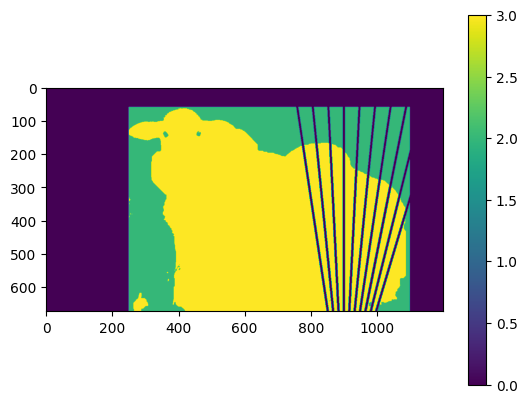

In [59]:
updated_mask = mask.copy()
for i in range(10):
    cv.line(updated_mask, (700 + (i+1) * 50, 0), (900, 1000), cv.GC_BGD, 5)
plt.imshow(updated_mask); plt.title(""); plt.colorbar()

Text(0.5, 1.0, '')

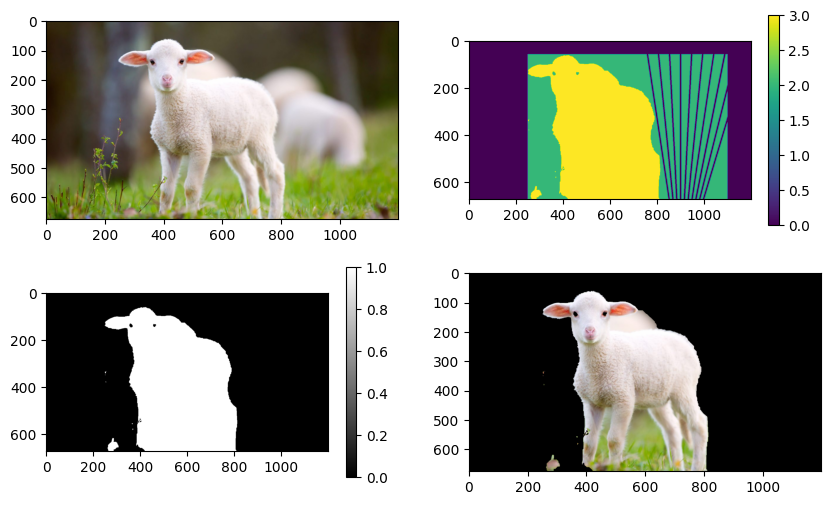

In [60]:
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
cv.grabCut(img, updated_mask, None, bgdModel, fgdModel, 5, mode=cv.GC_INIT_WITH_MASK)

mask2 = np.where((updated_mask == cv.GC_BGD) | (updated_mask == cv.GC_PR_BGD), 0, 1).astype('uint8')
res = cv.bitwise_and(img, img, mask=mask2)

plt.figure(figsize=(10,6))
plt.subplot(221); plt.imshow(img[...,::-1]); plt.title("")
plt.subplot(222); plt.imshow(updated_mask); plt.title(""); plt.colorbar()
plt.subplot(223); plt.imshow(mask2, cmap='gray'); plt.title(""); plt.colorbar()
plt.subplot(224); plt.imshow(res[...,::-1]); plt.title("")